  # **Import Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import shapiro, f_oneway, stats
from statsmodels.stats.multicomp import MultiComparison
from yellowbrick.regressor import ResidualsPlot, PredictionError
import joblib


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  # **Regression algorithms for farm areas**









In [2]:
# Load data
all_areas_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/output/final/data_integration_all_areas_final.csv")



In [3]:
all_areas_df.select_dtypes(include=['int64','float64'])



,index,farm,area_cod,area_size,CO2_emission_area,CO2_emission_ha,CO2_stock_area,CO2_stock_ha,balance_CO2_area,balance_CO2_ha,city_cod,state_cod,biome_cod,climate_cod,year
0,1,4576327,3,5.35,0.000000,0.000000,167.718896,31.349326,167.718896,31.349326,1100908,11,1,2,2021
1,2,4576327,12,0.27,1.996577,7.394729,8.463050,31.344631,6.466474,23.949902,1100908,11,1,2,2021
2,3,4576327,15,69.79,516.078138,7.394729,2044.337396,29.292698,1528.259257,21.897969,1100908,11,1,2,2021
3,4,4574927,3,3.23,0.000000,0.000000,101.258324,31.349326,101.258324,31.349326,1100908,11,1,2,2021
4,5,4574927,12,0.30,2.218419,7.394729,9.403389,31.344631,7.184971,23.949902,1100908,11,1,2,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22795,22796,13894,12,0.08,0.394706,4.933824,2.159577,26.994707,1.764871,22.060882,2312908,23,2,3,2021
22796,22797,4749410,3,2.08,0.000000,0.000000,76.117710,36.595053,76.117710,36.595053,2312908,23,2,3,2021
22797,22798,4749410,4,82.95,0.000000,0.000000,2347.975103,28.305908,2347.975103,28.305908,2312908,23,2,3,2021
22798,22799,4749410,12,0.68,3.355000,4.933824,18.356401,26.994707,15.001400,22.060882,2312908,23,2,3,2021


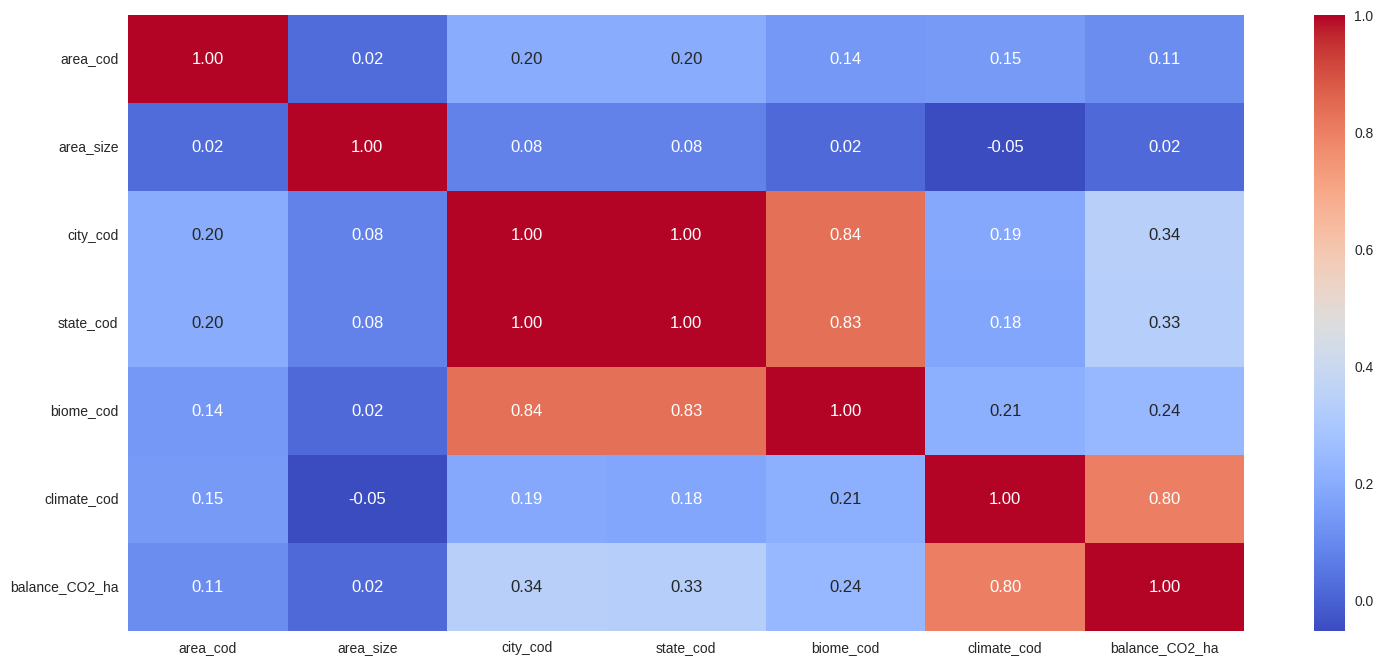

In [4]:

# Global Setup for xAI and Data Leak Prevention
features_xai = [
    'area_cod',     
    'area_size',    
    'city_cod',     
    'state_cod',    
    'biome_cod',    
    'climate_cod'   
]
target = 'balance_CO2_ha'

# Correlation only with allowed features and the target (No Data Leakage)
colunas_correlacao = features_xai + [target]
all_areas_df_corr = all_areas_df[colunas_correlacao]

figura = plt.figure(figsize=(18,8))
sns.heatmap(all_areas_df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()



In [5]:
all_areas_df.count()



,0
index,22800
farm,22800
area_cod,22800
area_name,22800
area_size,22800
CO2_emission_area,22800
CO2_emission_ha,22800
CO2_stock_area,22800
CO2_stock_ha,22800
balance_CO2_area,22800


  **Linear Regression - Simple**

In [6]:
# X is the single predictor attribute: climate_cod
X_areas = all_areas_df['climate_cod'].values
X_areas



array([2, 2, 2, ..., 3, 3, 3])

In [7]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df[target].values
Y_areas



array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

In [8]:
X_areas.shape, Y_areas.shape



((22800,), (22800,))

In [9]:
# Correlation coefficient
np.corrcoef(X_areas, Y_areas)



array([[1.        , 0.80127047],
       [0.80127047, 1.        ]])

In [10]:
# Transforming array into matrix (required for sklearn)
X_areas = X_areas.reshape(-1,1)
X_areas



array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [11]:
X_areas.shape



(22800, 1)

  **Simple Linear Regression - training and testing bases**

In [12]:
# Division of bases (75% train, 25% test)
X_areas_train, X_areas_test, Y_areas_train, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)



In [13]:
X_areas_train.shape, Y_areas_train.shape, X_areas_test.shape, Y_areas_test.shape



((17100, 1), (17100,), (5700, 1), (5700,))





  **Standardization, if necessary**

In [14]:
# We fit and transform the training set, but only transform the test set 
# using the exact parameters (mean and variance) learned from the training data.
scaler_areas_x = StandardScaler()
X_areas_train = scaler_areas_x.fit_transform((X_areas_train).reshape(-1,1))
X_areas_test = scaler_areas_x.transform((X_areas_test).reshape(-1,1))

scaler_areas_y = StandardScaler()
Y_areas_train = scaler_areas_y.fit_transform((Y_areas_train).reshape(-1,1))
Y_areas_test = scaler_areas_y.transform((Y_areas_test).reshape(-1,1))

X_areas_train, Y_areas_train, X_areas_test, Y_areas_test




(array([[ 2.04293687],
        [ 2.04293687],
        [-0.33024732],
        ...,
        [-0.33024732],
        [-0.33024732],
        [ 2.04293687]]),
 array([[ 1.33939139],
        [ 1.33939139],
        [-0.43073256],
        ...,
        [-0.68259947],
        [-0.68259947],
        [ 1.33939139]]),
 array([[ 0.61902636],
        [ 2.04293687],
        [-0.33024732],
        ...,
        [ 2.04293687],
        [-0.33024732],
        [-0.80488415]]),
 array([[ 0.7564848 ],
        [ 1.33939139],
        [-0.00878267],
        ...,
        [ 1.24779181],
        [-0.43073256],
        [-1.44795368]]))

  **Regression Model for training**

In [15]:
# Convert array to matrix
X_areas_train = X_areas_train.reshape(-1,1)
X_areas_train



array([[ 2.04293687],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [-0.33024732],
       [-0.33024732],
       [ 2.04293687]])

In [16]:
# Create the regression model (train)
simple_linear_regressor_train = LinearRegression()
simple_linear_regressor_train.fit(X_areas_train, Y_areas_train.ravel())



LinearRegression()

In [17]:
# score: algorithm quality metric (train)
simple_linear_regressor_train.score(X_areas_train, Y_areas_train)



0.6402051597659755

In [18]:
# Prevision (train)
prevision_simple_linear_regressor_train = simple_linear_regressor_train.predict(X_areas_train)
prevision_simple_linear_regressor_train



array([ 1.63461143,  1.63461143, -0.26424019, ..., -0.26424019,
       -0.26424019,  1.63461143])

In [19]:
# Real data
Y_areas_train



array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [20]:
# Mean absolute error
mean_absolute_error(Y_areas_train, prevision_simple_linear_regressor_train)



0.46766654955311804

In [21]:
# Mean squared error
mean_squared_error(Y_areas_train, prevision_simple_linear_regressor_train)



0.35979484023402447

In [22]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_train, prevision_simple_linear_regressor_train))



0.5998290091634653

In [23]:
# Prediction with a standardized climate code (value 15) = estimated value of carbon/ha
simple_linear_regressor_train.intercept_ + scaler_areas_x.transform([[15]])[0][0]



4.890757896079168

  **Regression Model for testing**

In [24]:
# Convert array to matrix
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test



array([[ 0.61902636],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [ 2.04293687],
       [-0.33024732],
       [-0.80488415]])

In [25]:
# score: algorithm quality metric (test)
simple_linear_regressor_train.score(X_areas_test, Y_areas_test)



0.6474472065351384

In [26]:
# Prevision (test)
prevision_simple_linear_regressor_test = simple_linear_regressor_train.predict(X_areas_test)
prevision_simple_linear_regressor_test



array([ 0.49530046,  1.63461143, -0.26424019, ...,  1.63461143,
       -0.26424019, -0.64401052])

In [27]:
# Real data
Y_areas_test



array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [28]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_simple_linear_regressor_test)



0.46201992579723833

In [29]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test)



0.34606305802644727

In [30]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test))



0.5882712452826904

In [31]:
# Prediction with a value  (area 15) = estimated value of carbon/ha
simple_linear_regressor_train.intercept_ + scaler_areas_x.transform([[15]])[0][0]


4.890757896079168

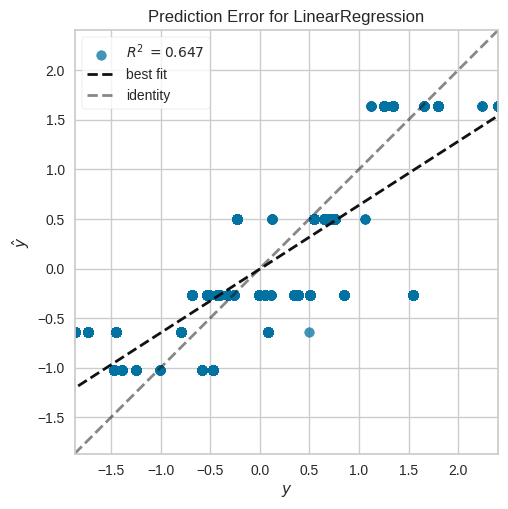

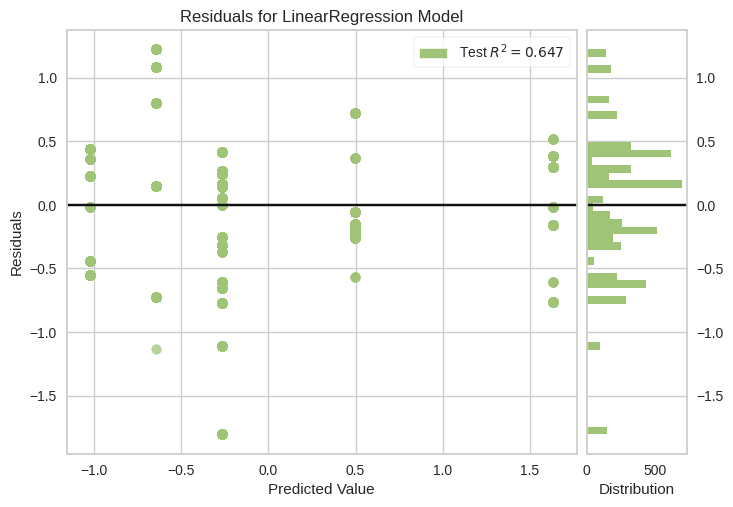

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [32]:
# Error Visualization with Graphs (Yellowbrick) - Simple Linear Regression
visualizer_pe = PredictionError(simple_linear_regressor_train, is_fitted=True)
visualizer_pe.score(X_areas_test, Y_areas_test.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(simple_linear_regressor_train, is_fitted=True)
visualizer_rp.score(X_areas_test, Y_areas_test.ravel())
visualizer_rp.show()


  # **Linear Regression - Multiple**

In [33]:
# X matrix composed of the 6 multi-criteria features (area code, Size, City, State, Biome, Climate)
X_areas_mult = all_areas_df[features_xai].values
X_areas_mult



array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [34]:
# # Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df[target].values
Y_areas_mult



array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

  **Multiple Linear Regression - training and testing bases**

In [35]:
# Division of bases (75% train, 25% test)
X_areas_mult_train, X_areas_mult_test, Y_areas_mult_train, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)



In [36]:
X_areas_mult_train.shape, Y_areas_mult_train.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape



((17100, 6), (17100,), (5700, 6), (5700,))

  **Standardization, if necessary**





In [37]:
scaler_areas_x_mult = StandardScaler()
X_areas_mult_train = scaler_areas_x_mult.fit_transform((X_areas_mult_train))
X_areas_mult_test = scaler_areas_x_mult.transform((X_areas_mult_test)) 

scaler_areas_y_mult = StandardScaler()
Y_areas_mult_train = scaler_areas_y_mult.fit_transform((Y_areas_mult_train).reshape(-1, 1)) 
Y_areas_mult_test = scaler_areas_y_mult.transform((Y_areas_mult_test).reshape(-1, 1))

X_areas_mult_train, Y_areas_mult_train, X_areas_mult_test, Y_areas_mult_test



(array([[ 0.41451135, -0.15136168, -0.47463678, -0.49368236, -0.44503961,
          2.04293687],
        [ 0.41451135, -0.16520356, -0.47463678, -0.49368236, -0.44503961,
          2.04293687],
        [ 0.41451135,  1.90797261,  0.92012512,  0.92456378,  1.25012909,
         -0.33024732],
        ...,
        [-0.07364724,  5.29032881,  0.92012512,  0.92456378,  1.25012909,
         -0.33024732],
        [-0.07364724, -0.13627713,  0.92012512,  0.92456378,  1.25012909,
         -0.33024732],
        [ 0.41451135, -0.08802038, -0.47463678, -0.49368236, -0.44503961,
          2.04293687]]),
 array([[ 1.33939139],
        [ 1.33939139],
        [-0.43073256],
        ...,
        [-0.68259947],
        [-0.68259947],
        [ 1.33939139]]),
 array([[ 2.04170663, -0.16440964,  0.36108383,  0.35726532,  0.68507286,
          0.61902636],
        [ 0.41451135, -0.16444416, -0.47463678, -0.49368236, -0.44503961,
          2.04293687],
        [-0.96860464, -0.15433026,  0.92024292,  0.92456

  **Regression Model for training**

In [38]:
# Create the regression model (train)
mult_linear_regressor_train = LinearRegression()
mult_linear_regressor_train.fit(X_areas_mult_train, Y_areas_mult_train.ravel())



LinearRegression()

In [39]:
# score: algorithm quality metric (train)
mult_linear_regressor_train.score(X_areas_mult_train, Y_areas_mult_train)



0.7440919786026767

In [40]:
# Prevision (train)
prevision_mult_linear_regressor_train = mult_linear_regressor_train.predict(X_areas_mult_train)
prevision_mult_linear_regressor_train



array([ 1.47308489,  1.47263003, -0.20198712, ..., -0.05431278,
       -0.232637  ,  1.47516636])

In [41]:
# Real data
Y_areas_mult_train



array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [42]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_train, prevision_mult_linear_regressor_train)



0.40285018862148314

In [43]:
# Mean squared error
mean_squared_error(Y_areas_mult_train, prevision_mult_linear_regressor_train)



0.2559080213973232

In [44]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_train, prevision_mult_linear_regressor_train))



0.5058735231234416

  **Regression Model for testing**

In [45]:
# score: algorithm quality metric (test)
mult_linear_regressor_train.score(X_areas_mult_test, Y_areas_mult_test)



0.7447778959678222

In [46]:
# Prevision (test)
prevision_mult_linear_regressor_test = mult_linear_regressor_train.predict(X_areas_mult_test)
prevision_mult_linear_regressor_test



array([ 0.39943652,  1.47265499,  0.41376057, ...,  1.5092642 ,
       -0.26883673, -1.18996324])

In [47]:
# Real data
Y_areas_mult_test



array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [48]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)



0.40035918899141537

In [49]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)



0.2505240163587656

In [50]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test))


0.5005237420530275

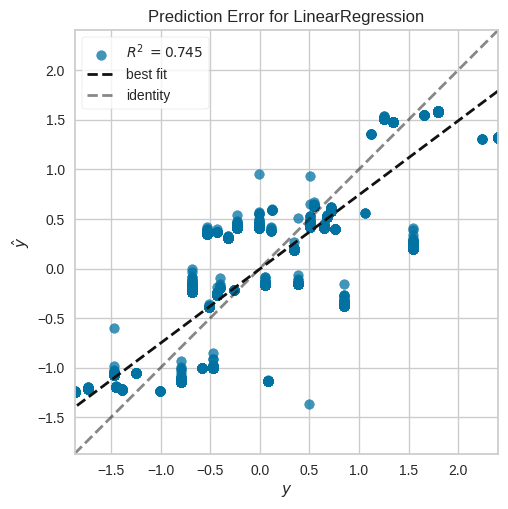

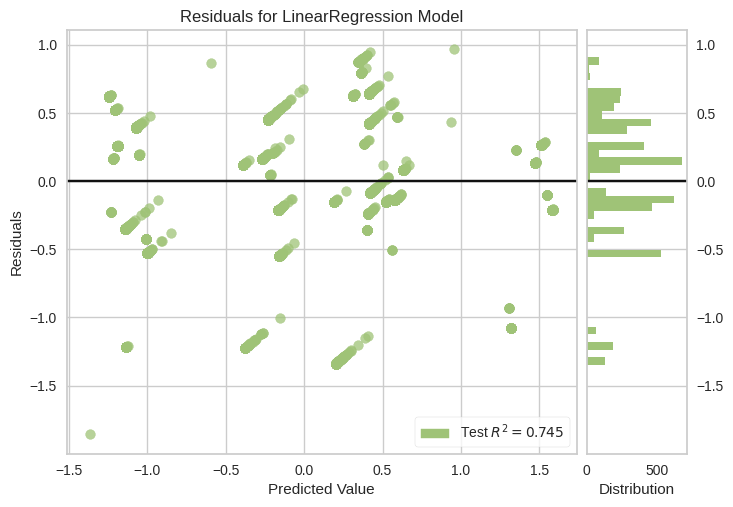

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [51]:
# Error Visualization with Graphs (Yellowbrick) - Multiple Linear Regression
visualizer_pe = PredictionError(mult_linear_regressor_train, is_fitted=True)
visualizer_pe.score(X_areas_mult_test, Y_areas_mult_test.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(mult_linear_regressor_train, is_fitted=True)
visualizer_rp.score(X_areas_mult_test, Y_areas_mult_test.ravel())
visualizer_rp.show()


  # **Polynomial Regression**

In [52]:
# X is the single predictor feature: climate_cod
X_areas = all_areas_df['climate_cod'].values
X_areas



array([2, 2, 2, ..., 3, 3, 3])

In [53]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df[target].values
Y_areas



array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

  **Polynomial Linear Regression - training and testing bases**

In [54]:
# Division of bases (75% train, 25% test)
X_areas_train, X_areas_test, Y_areas_train, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)



In [55]:
scaler_polynomial_x = StandardScaler()
X_areas_train  = scaler_polynomial_x.fit_transform(X_areas_train.reshape(-1,1))
X_areas_test = scaler_polynomial_x.transform(X_areas_test.reshape(-1,1))

scaler_polynomial_y = StandardScaler()
Y_areas_train  = scaler_polynomial_y.fit_transform(Y_areas_train.reshape(-1,1))
Y_areas_test = scaler_polynomial_y.transform(Y_areas_test.reshape(-1,1))




In [56]:
# Apply degree to the polynomial
polynomial_degree = PolynomialFeatures(degree=2) 



  **Regression Model for training**

In [57]:
X_areas_train.shape, Y_areas_train.shape



((17100, 1), (17100, 1))

In [58]:
# Transforming array into matrix (required for sklearn)
X_areas_train = X_areas_train.reshape(-1,1)
X_areas_train



array([[ 2.04293687],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [-0.33024732],
       [-0.33024732],
       [ 2.04293687]])

In [59]:
# Apply polynominal degree in X
X_areas_train_poly = polynomial_degree.fit_transform(X_areas_train)
X_areas_train_poly.shape



(17100, 3)

In [60]:
# Create the regression model
poly_simple_linear_regressor_train = LinearRegression()
poly_simple_linear_regressor_train.fit(X_areas_train_poly, Y_areas_train.ravel())



LinearRegression()

In [61]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_train.score(X_areas_train_poly, Y_areas_train)



0.650252795793373

In [62]:
# Prevision
prevision_poly_simple_linear_regressor_train = poly_simple_linear_regressor_train.predict(X_areas_train_poly)
prevision_poly_simple_linear_regressor_train



array([ 1.51136156,  1.51136156, -0.207015  , ..., -0.207015  ,
       -0.207015  ,  1.51136156])

In [63]:
# Real data
Y_areas_train



array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [64]:
# Mean absolute error
mean_absolute_error(Y_areas_train, prevision_poly_simple_linear_regressor_train)



0.4498088679114038

In [65]:
# Mean squared error
mean_squared_error(Y_areas_train, prevision_poly_simple_linear_regressor_train)



0.3497472042066268

In [66]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_train, prevision_poly_simple_linear_regressor_train))



0.5913942882769725

  **Regression Model for testing**

In [67]:
X_areas_test.shape, Y_areas_test.shape



((5700, 1), (5700, 1))

In [68]:
# Transforming array into matrix (required for sklearn)
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test



array([[ 0.61902636],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [ 2.04293687],
       [-0.33024732],
       [-0.80488415]])

In [69]:
# Apply polynominal degree in X
X_areas_test_poly = polynomial_degree.transform(X_areas_test) 
X_areas_test_poly.shape



(5700, 3)

In [70]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_train.score(X_areas_test_poly, Y_areas_test)



0.6590801343088739

In [71]:
# Prevision
prevision_poly_simple_linear_regressor_test = poly_simple_linear_regressor_train.predict(X_areas_test_poly)
prevision_poly_simple_linear_regressor_test



array([ 0.61375079,  1.51136156, -0.207015  , ...,  1.51136156,
       -0.207015  , -0.68410548])

In [72]:
# Real data
Y_areas_test



array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [73]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)



0.4416265902629157

In [74]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)



0.33464426732671926

In [75]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test))


0.5784844572905302

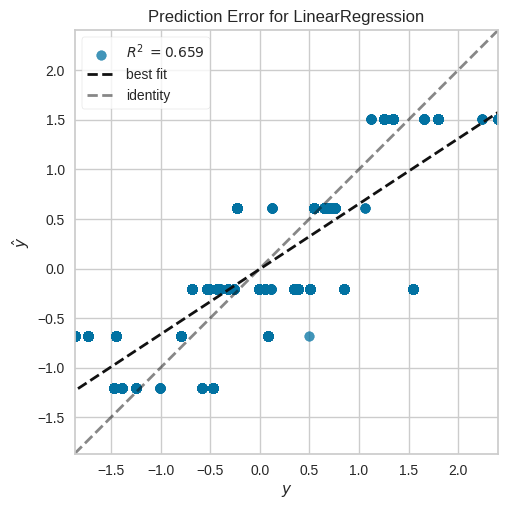

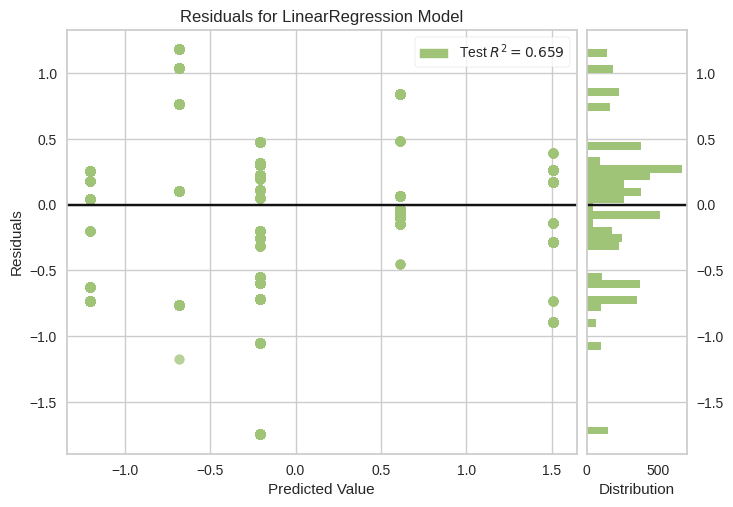

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [76]:
# Error Visualization with Graphs (Yellowbrick) - Polynomial Regression
visualizer_pe = PredictionError(poly_simple_linear_regressor_train, is_fitted=True)
visualizer_pe.score(X_areas_test_poly, Y_areas_test.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(poly_simple_linear_regressor_train, is_fitted=True)
visualizer_rp.score(X_areas_test_poly, Y_areas_test.ravel())
visualizer_rp.show()



  # **Polynomial Regression - Multiple**

In [ ]:
# X composed of attributes: 'area_cod', 'area_size', 'city_cod', 'state_cod', 'biome_cod', 'climate_cod'     
    
X_areas_mult = all_areas_df[features_xai].values
X_areas_mult



array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [78]:
# Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df[target].values
Y_areas_mult



array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

  **Multiple Linear Regression - training and testing bases**

In [79]:
# Division of bases (75% train, 25% test)
X_areas_mult_train, X_areas_mult_test, Y_areas_mult_train, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)



In [80]:
X_areas_mult_train.shape, Y_areas_mult_train.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape



((17100, 6), (17100,), (5700, 6), (5700,))

In [81]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=2) 



  **Standardization, in this algorithm is very important**

In [82]:
scaler_mult_polynomial_x = StandardScaler()
X_areas_mult_train  = scaler_mult_polynomial_x.fit_transform(X_areas_mult_train)
X_areas_mult_test = scaler_mult_polynomial_x.transform(X_areas_mult_test)

scaler_mult_polynomial_y = StandardScaler()
Y_areas_mult_train = scaler_mult_polynomial_y.fit_transform(Y_areas_mult_train.reshape(-1, 1))
Y_areas_mult_test = scaler_mult_polynomial_y.transform(Y_areas_mult_test.reshape(-1, 1))




  **Regression Model for training**

In [83]:
# Apply polynominal degree in X
X_areas_multi_poly_train = mult_polynomial_degree.fit_transform(X_areas_mult_train)



In [84]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    poly = LinearRegression()
    scores = cross_val_score(poly, X_areas_multi_poly_train, Y_areas_mult_train, cv=kfold)
    results_polynomial.append(scores.mean())




In [85]:
# Create the regression model (for train data)
poly_mult_linear_regressor = LinearRegression()
poly_mult_linear_regressor.fit(X_areas_multi_poly_train, Y_areas_mult_train.ravel())



LinearRegression()

In [86]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_train , Y_areas_mult_train)



0.8819054745288298

In [87]:
# Prevision
prevision_poly_mult_linear_regressor_train = poly_mult_linear_regressor.predict(X_areas_multi_poly_train)
prevision_poly_mult_linear_regressor_train



array([ 1.23867364,  1.24501898, -0.46904363, ..., -0.26197955,
       -0.40165177,  1.2096314 ])

In [88]:
# Real data
Y_areas_mult_train



array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [89]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_train, prevision_poly_mult_linear_regressor_train)



0.2538457610625985

In [90]:
# Mean squared error
mean_squared_error(Y_areas_mult_train, prevision_poly_mult_linear_regressor_train)



0.11809452547117018

In [91]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_train, prevision_poly_mult_linear_regressor_train))



0.3436488403460285





  **Regression Model for testing**

In [92]:
# Apply polynominal degree in X
X_areas_multi_poly_test = mult_polynomial_degree.transform(X_areas_mult_test) 



In [93]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_test , Y_areas_mult_test)



0.8821847816625706

In [94]:
# Prevision
prevision_poly_mult_linear_regressor_test = poly_mult_linear_regressor.predict(X_areas_multi_poly_test)
prevision_poly_mult_linear_regressor_test



array([ 0.59783036,  1.24467087,  0.05511831, ...,  1.34921069,
       -0.54619392, -1.36117271])

In [95]:
# Real Data
Y_areas_mult_test



array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [96]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)



0.2504763745976724

In [97]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)



0.11564649464043465

In [98]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test))


0.3400683675975092

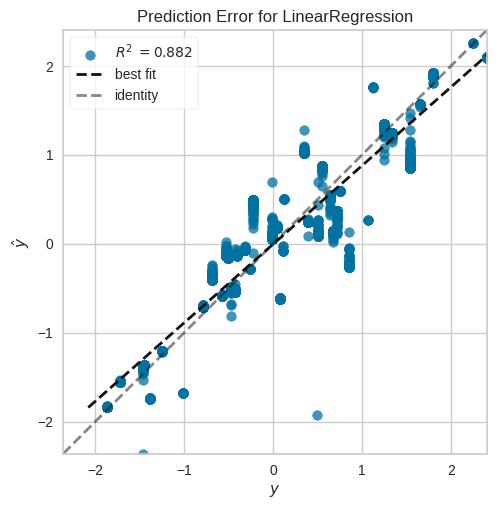

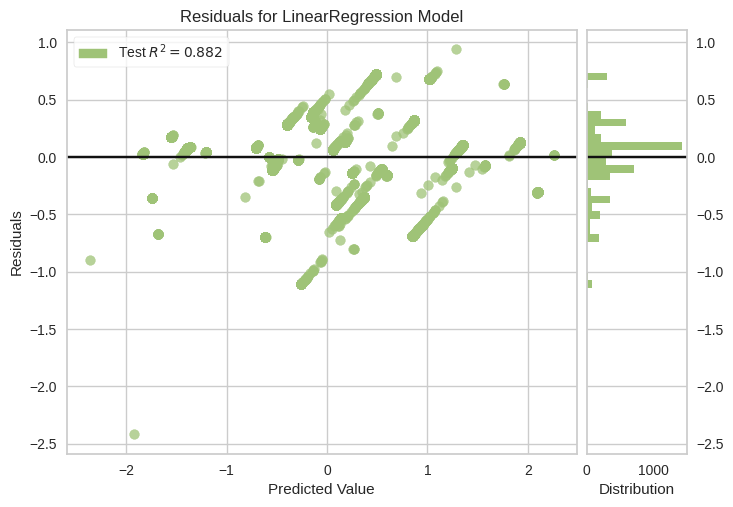

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [99]:
# Error Visualization with Graphs (Yellowbrick) - Polynomial Regression Multiple
visualizer_pe = PredictionError(poly_mult_linear_regressor, is_fitted=True)
visualizer_pe.score(X_areas_multi_poly_test, Y_areas_mult_test.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(poly_mult_linear_regressor, is_fitted=True)
visualizer_rp.score(X_areas_multi_poly_test, Y_areas_mult_test.ravel())
visualizer_rp.show()


  # **Decision Tree Regression**

In [ ]:
# X is the attribute: area_cod (predictor attribute) => (area_cod: 2, city_cod: 11, climate_cod: 17)
X_areas_tree = all_areas_df[['area_cod']].values
X_areas_tree



array([[ 3],
       [12],
       [15],
       ...,
       [ 4],
       [12],
       [15]])

In [101]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree  = all_areas_df[target].values
Y_areas_tree




array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

  **Decision Tree Regression - training and testing bases**

In [102]:
# Division of bases (75% train, 25% test)
X_areas_tree_train, X_areas_tree_test, Y_areas_tree_train, Y_areas_tree_test = train_test_split(X_areas_tree, Y_areas_tree, test_size = 0.25, random_state = 0)
X_areas_tree_train.shape, Y_areas_tree_train.shape, X_areas_tree_test.shape, Y_areas_tree_test.shape



((17100, 1), (17100,), (5700, 1), (5700,))

  **Decision Tree for training**

In [103]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree_train, Y_areas_tree_train.ravel())



DecisionTreeRegressor()

In [104]:
# Prevision
prevision_areas_tree_train = regressor_areas_tree.predict(X_areas_tree_train)
prevision_areas_tree_train[:10]



array([35.67371324, 35.67371324, 35.67371324, 34.03334075, 29.90336477,
       35.67371324, 35.67371324, 35.67371324, 40.64426883, 29.90336477])

In [105]:
Y_areas_tree_train[:10]



array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [106]:
# Score
regressor_areas_tree.score(X_areas_tree_train,Y_areas_tree_train)



0.258375460165821

In [107]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_train, prevision_areas_tree_train)



6.465009972315875

In [108]:
# Mean squared error
mean_squared_error(Y_areas_tree_train, prevision_areas_tree_train)



67.040750530816

In [109]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_train, prevision_areas_tree_train))



8.187841628342357





  **Decision Tree for testing**

In [110]:
# Prevision
prevision_areas_tree_test = regressor_areas_tree.predict(X_areas_tree_test)
prevision_areas_tree_test[:10]



array([35.76634525, 35.67371324, 32.87159106, 34.03334075, 32.87159106,
       40.25314972, 35.76634525, 32.87159106, 35.67371324, 29.90336477])

In [111]:
Y_areas_tree_test[:10]



array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [112]:
# Score
regressor_areas_tree.score(X_areas_tree_test,Y_areas_tree_test)



0.25358880028851516

In [113]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_test, prevision_areas_tree_test)



6.459532175193367

In [114]:
# Mean squared error
mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test)



66.23141048431235

In [115]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test))


8.138268273061065

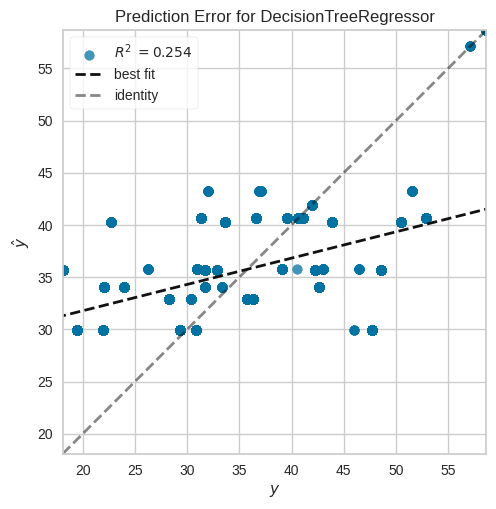

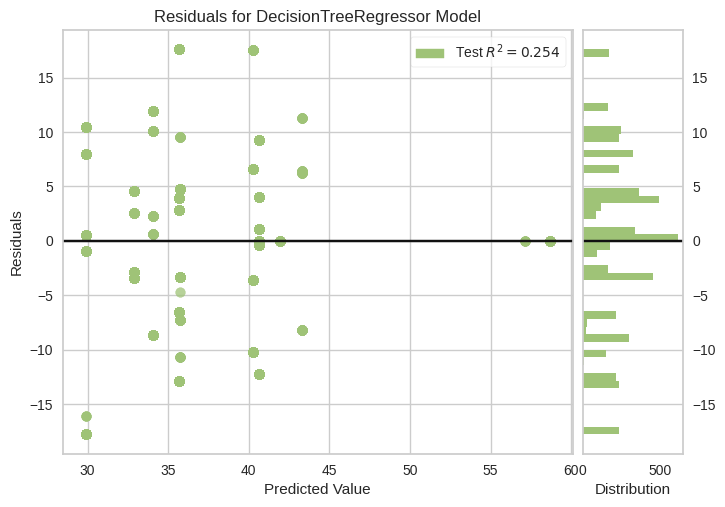

<Axes: title={'center': 'Residuals for DecisionTreeRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [116]:
# Error Visualization with Graphs (Yellowbrick) - Decision Tree Regression
visualizer_pe = PredictionError(regressor_areas_tree, is_fitted=True)
visualizer_pe.score(X_areas_tree_test, Y_areas_tree_test.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(regressor_areas_tree, is_fitted=True)
visualizer_rp.score(X_areas_tree_test, Y_areas_tree_test.ravel())
visualizer_rp.show()


  # Decision Tree Regression - **Multiple**

In [ ]:
# X composed of attributes: 'area_cod', 'area_size', 'city_cod', 'state_cod', 'biome_cod', 'climate_cod'
X_areas_tree_mult = all_areas_df[features_xai].values
X_areas_tree_mult



array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [118]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree_mult  = all_areas_df[target].values.reshape(-1, 1)
Y_areas_tree_mult




array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

  **Multiple Decision Tree Regression - training and testing bases**

In [119]:
# # Division of bases (75% train, 25% test)
X_areas_tree_mult_train, X_areas_tree_mult_test, Y_areas_tree_mult_train, Y_areas_tree_mult_test = train_test_split(X_areas_tree_mult, Y_areas_tree_mult, test_size = 0.25, random_state = 0)
X_areas_tree_mult_train.shape, Y_areas_tree_mult_train.shape, X_areas_tree_mult_test.shape, Y_areas_tree_mult_test.shape



((17100, 6), (17100, 1), (5700, 6), (5700, 1))

  **Multiple Decision Tree for training**

In [120]:
regressor_areas_tree_mult_train = DecisionTreeRegressor()
regressor_areas_tree_mult_train.fit(X_areas_tree_mult_train, Y_areas_tree_mult_train.ravel())



DecisionTreeRegressor()

In [121]:
prevision_area_tree_mult_train = regressor_areas_tree_mult_train.predict(X_areas_tree_mult_train)
prevision_area_tree_mult_train[:10]



array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [122]:
Y_areas_tree_mult_train[:10].ravel()



array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [123]:
# Score
regressor_areas_tree_mult_train.score(X_areas_tree_mult_train,Y_areas_tree_mult_train)



1.0

In [125]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_train, prevision_area_tree_mult_train)



3.310595202785078e-13

In [126]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_train, prevision_area_tree_mult_train)



1.7085985179608268e-25

In [ ]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_train, prevision_area_tree_mult_train))




4.1335197083851273e-13

In [128]:
# Cross Validation Decision Tree Regression - train(Multiple)
results_tree_train = []
for i in range(60):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    tree = DecisionTreeRegressor()
    scores = cross_val_score(tree, X_areas_tree_mult_train, Y_areas_tree_mult_train, cv=kfold)
    results_tree_train.append(scores.mean())



  **Multiple Decision Tree for testing**

In [129]:
prevision_area_tree_mult_test = regressor_areas_tree_mult_train.predict(X_areas_tree_mult_test)
prevision_area_tree_mult_test[:10]



array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [130]:
Y_areas_tree_mult_test[:10].ravel()



array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [131]:
# Score
regressor_areas_tree_mult_train.score(X_areas_tree_mult_test,Y_areas_tree_mult_test)



1.0

In [133]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)



3.360811044666135e-13

In [134]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)



1.7543803955152212e-25

In [135]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test))


4.1885324345350617e-13

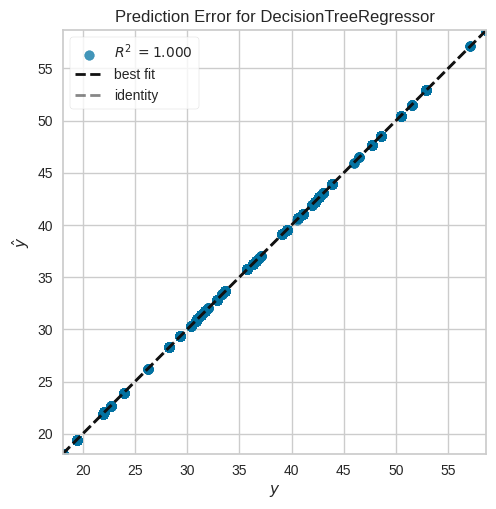

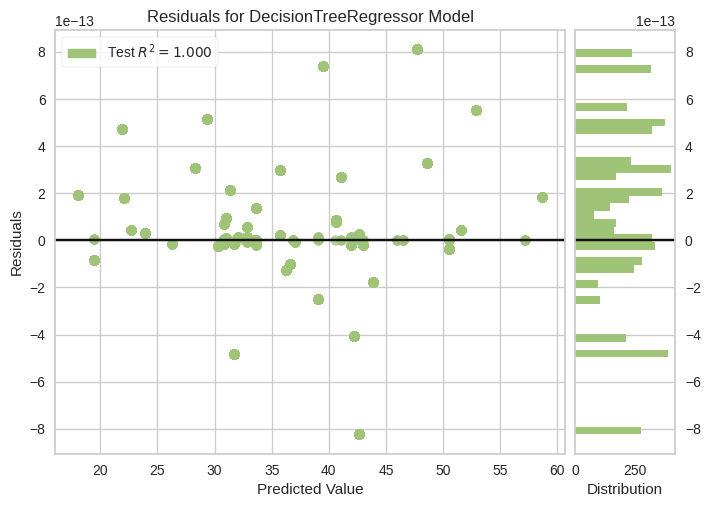

<Axes: title={'center': 'Residuals for DecisionTreeRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [136]:
# Error Visualization with Graphs (Yellowbrick) - Multiple Decision Tree
visualizer_pe = PredictionError(regressor_areas_tree_mult_train, is_fitted=True)
visualizer_pe.score(X_areas_tree_mult_test, Y_areas_tree_mult_test.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(regressor_areas_tree_mult_train, is_fitted=True)
visualizer_rp.score(X_areas_tree_mult_test, Y_areas_tree_mult_test.ravel())
visualizer_rp.show()


  # **Random Forest Regression**

In [137]:
# X is the attribute: area_cod (predictor attribute)
X_areas_random_forest = all_areas_df[['climate_cod']].values
X_areas_random_forest



array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [138]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest  = all_areas_df[target].values.reshape(-1, 1)
Y_areas_random_forest



array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

  **Random Forest Regression - training and testing bases**

In [139]:
# Division of bases (75% train, 25% test)
X_areas_random_forest_train, X_areas_random_forest_test, Y_areas_random_forest_train, Y_areas_random_forest_test = train_test_split(X_areas_random_forest, Y_areas_random_forest, test_size = 0.25, random_state = 0)
X_areas_random_forest_train.shape, Y_areas_random_forest_train.shape, X_areas_random_forest_test.shape, Y_areas_random_forest_test.shape



((17100, 1), (17100, 1), (5700, 1), (5700, 1))

  **Random Forest for training**

In [140]:
# Convert to matrix
X_areas_random_forest_train = X_areas_random_forest_train.reshape(-1,1)
X_areas_random_forest_train.shape



(17100, 1)

In [141]:
regressor_random_forest_areas_train = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_train.fit(X_areas_random_forest_train,Y_areas_random_forest_train.ravel())



RandomForestRegressor()

In [142]:
# Score
regressor_random_forest_areas_train.score(X_areas_random_forest_train, Y_areas_random_forest_train)



0.7151485665413553

In [143]:
# Prevision (train)
prevision_random_forest_areas_train = regressor_random_forest_areas_train.predict(X_areas_random_forest_train)
prevision_random_forest_areas_train



array([50.50469186, 50.50469186, 35.7299216 , ..., 35.7299216 ,
       35.7299216 , 50.50469186])

In [144]:
# Real data
Y_areas_random_forest_train.ravel()



array([48.5622402 , 48.5622402 , 31.73235842, ..., 29.33767283,
       29.33767283, 48.5622402 ])

In [145]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_train, prevision_random_forest_areas_train)



4.193365404328096

In [146]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_train, prevision_random_forest_areas_train)



25.7497599703432

In [147]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_train, prevision_random_forest_areas_train))



5.074422131666147

  **Random Forest for testing**

In [148]:
# Convert to matrix
X_areas_random_forest_test = X_areas_random_forest_test.reshape(-1,1)
X_areas_random_forest_test.shape




(5700, 1)

In [149]:
# Score
regressor_random_forest_areas_train.score(X_areas_random_forest_test, Y_areas_random_forest_test)



0.7207686548966823

In [150]:
# Prevision (test)
prevision_random_forest_areas_test = regressor_random_forest_areas_train.predict(X_areas_random_forest_test)
prevision_random_forest_areas_test



array([40.0363687 , 50.50469186, 35.7299216 , ..., 50.50469186,
       35.7299216 , 24.40503051])

In [151]:
# Real data
Y_areas_random_forest_test.ravel()



array([43.02011476, 48.5622402 , 35.74414912, ..., 47.69133504,
       31.73235842, 22.06088245])

In [152]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)



4.133405791351267

In [153]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)



24.77707441256653

In [154]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test))


4.977657522627138

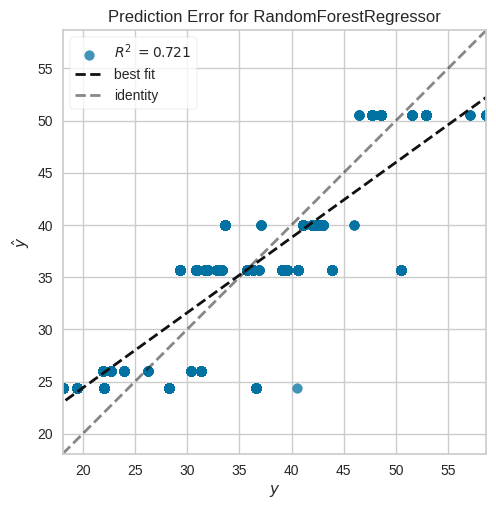

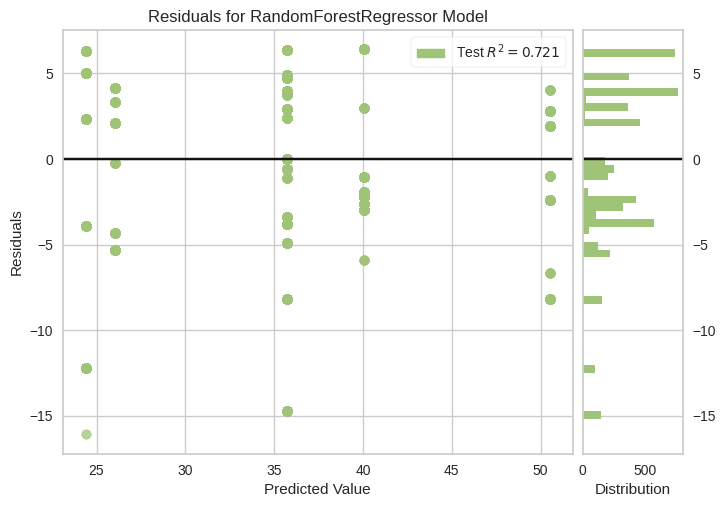

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [155]:
# Error Visualization with Graphs (Yellowbrick) - Random Forest
visualizer_pe = PredictionError(regressor_random_forest_areas_train, is_fitted=True)
visualizer_pe.score(X_areas_random_forest_test, Y_areas_random_forest_test.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(regressor_random_forest_areas_train, is_fitted=True)
visualizer_rp.score(X_areas_random_forest_test, Y_areas_random_forest_test.ravel())
visualizer_rp.show()



  # **Random Forest Regression - Multiple**

In [ ]:
# X composed of attributes: 'area_cod', 'area_size', 'city_cod', 'state_cod', 'biome_cod', 'climate_cod'
X_areas_random_forest_mult = all_areas_df[features_xai].values
X_areas_random_forest_mult



array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [157]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest_mult  = all_areas_df[target].values
Y_areas_random_forest_mult[:10]




array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

  **Multiple Random Forest Regression - training and testing bases**

In [158]:
# Division of bases (75% train, 25% test)
X_areas_random_forest_mult_train, X_areas_random_forest_mult_test, Y_areas_random_forest_mult_train, Y_areas_random_forest_mult_test = train_test_split(X_areas_random_forest_mult, Y_areas_random_forest_mult, test_size = 0.25, random_state = 0)
X_areas_random_forest_mult_train.shape, Y_areas_random_forest_mult_train.shape, X_areas_random_forest_mult_test.shape, Y_areas_random_forest_mult_test.shape



((17100, 6), (17100,), (5700, 6), (5700,))

  **Multiple Random Forest for training**

In [159]:
# Params tunning
param = {'n_estimators': [2,10,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult_train,Y_areas_random_forest_mult_train.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)



best_param:  {'n_estimators': 80}
best_result (score):  0.9996027788918042


In [160]:
regressor_random_forest_areas_mult_train = RandomForestRegressor(n_estimators=100, random_state=0)
regressor_random_forest_areas_mult_train.fit(X_areas_random_forest_mult_train,Y_areas_random_forest_mult_train.ravel())



RandomForestRegressor(random_state=0)

In [161]:
# Score
regressor_random_forest_areas_mult_train.score(X_areas_random_forest_mult_train, Y_areas_random_forest_mult_train)



0.9999621542023237

In [162]:
# Prevision (train)
prevision_random_forest_areas_mult_train = regressor_random_forest_areas_mult_train.predict(X_areas_random_forest_mult_train)
prevision_random_forest_areas_mult_train



array([48.5622402 , 48.5622402 , 31.73235842, ..., 29.33767283,
       29.33767283, 48.5622402 ])

In [163]:
# Real data
Y_areas_random_forest_mult_train



array([48.5622402 , 48.5622402 , 31.73235842, ..., 29.33767283,
       29.33767283, 48.5622402 ])

In [165]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_train, prevision_random_forest_areas_mult_train)



0.0008856136005293938

In [166]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_train, prevision_random_forest_areas_mult_train)



0.003421152543338912

In [167]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_train, prevision_random_forest_areas_mult_train))



0.058490619276418264





  **Multiple Random Forest for testing**

In [168]:
# Score
regressor_random_forest_areas_mult_train.score(X_areas_random_forest_mult_test, Y_areas_random_forest_mult_test)



0.9998969553809287

In [169]:
# Prevision (test)
prevision_random_forest_areas_mult_test = regressor_random_forest_areas_mult_train.predict(X_areas_random_forest_mult_test)
prevision_random_forest_areas_mult_test



array([43.02011476, 48.5622402 , 35.74414912, ..., 47.69133504,
       31.73235842, 22.06088245])

In [170]:
# Real data
Y_areas_random_forest_mult_test



array([43.02011476, 48.5622402 , 35.74414912, ..., 47.69133504,
       31.73235842, 22.06088245])

In [172]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)



0.0019887111150490135

In [173]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)



0.00914347274873625

In [174]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test))


0.0956215077727613

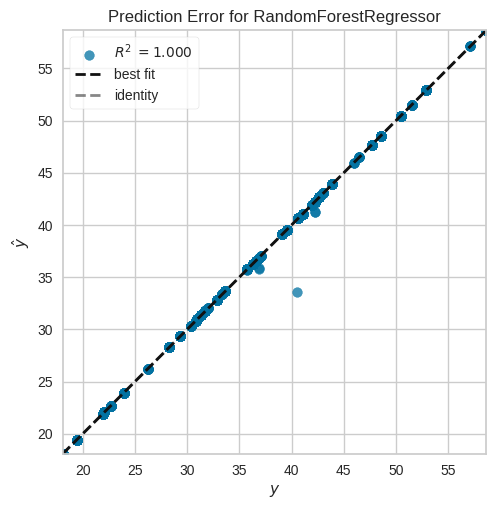

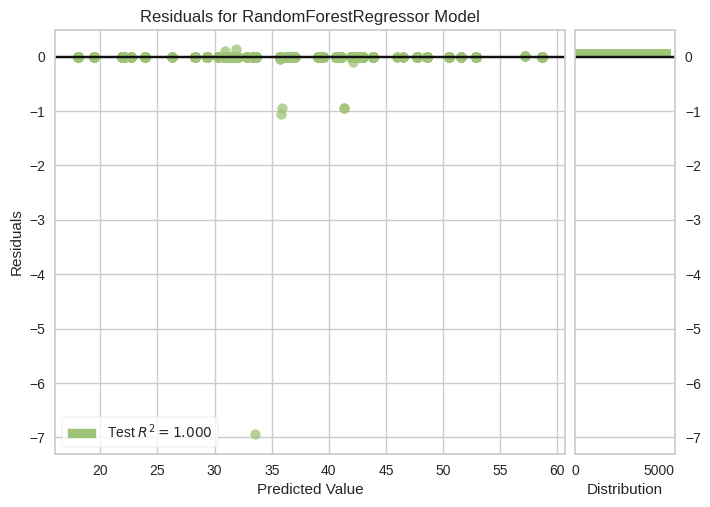

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [175]:
# Error Visualization with Graphs (Yellowbrick) - Multiple Random Forest
visualizer_pe = PredictionError(regressor_random_forest_areas_mult_train, is_fitted=True)
visualizer_pe.score(X_areas_random_forest_mult_test, Y_areas_random_forest_mult_test.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(regressor_random_forest_areas_mult_train, is_fitted=True)
visualizer_rp.score(X_areas_random_forest_mult_test, Y_areas_random_forest_mult_test.ravel())
visualizer_rp.show()


In [177]:
# Cross Validation Random Forest Regression - train (Multiple)
results_random_forest_train = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  
  # n_jobs=-1 It uses all processor cores to speed up the process.
  # n_estimators kept at 15 to avoid taking long time with cross-validation.
  random_forest = RandomForestRegressor(n_estimators=15, n_jobs=-1) 
  
  scores = cross_val_score(random_forest, X_areas_random_forest_mult_train, Y_areas_random_forest_mult_train.ravel(), cv=kfold)
  results_random_forest_train.append(scores.mean())


  # **Neural Network Regression**

In [178]:
# X is the attribute: climate cod (predictor attribute)
X_areas_rna = all_areas_df[['climate_cod']].values
X_areas_rna



array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [179]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna  = all_areas_df[target].values
Y_areas_rna




array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

  **Neural Network Regression - training and testing bases**

In [180]:
# Division of bases (75% train, 25% test)
X_areas_rna_train, X_areas_rna_test, Y_areas_rna_train, Y_areas_rna_test = train_test_split(X_areas_rna, Y_areas_rna, test_size = 0.25, random_state = 0)
X_areas_rna_train.shape, Y_areas_rna_train.shape, X_areas_rna_test.shape, Y_areas_rna_test.shape



((17100, 1), (17100,), (5700, 1), (5700,))

  **Neural Network for training**

In [181]:
# Starndatization X
scaler_areas_rna_x_train = StandardScaler()
X_areas_rna_train_scaled  = scaler_areas_rna_x_train.fit_transform(X_areas_rna_train.reshape(-1,1))
X_areas_rna_train_scaled.ravel()



array([ 2.04293687,  2.04293687, -0.33024732, ..., -0.33024732,
       -0.33024732,  2.04293687])

In [182]:
# Starndatization Y
scaler_areas_rna_y_train = StandardScaler()
Y_areas_rna_train_scaled  = scaler_areas_rna_y_train.fit_transform(Y_areas_rna_train.reshape(-1,1))
Y_areas_rna_train_scaled.ravel()



array([ 1.33939139,  1.33939139, -0.43073256, ..., -0.68259947,
       -0.68259947,  1.33939139])

In [183]:
regressor_rna_areas_train = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas_train.fit(X_areas_rna_train_scaled, Y_areas_rna_train_scaled.ravel())



MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [184]:
regressor_rna_areas_train.score(X_areas_rna_train_scaled, Y_areas_rna_train_scaled)



0.7147811235072017

In [185]:
# Prevision
prevision_rna_areas_train = regressor_rna_areas_train.predict(X_areas_rna_train_scaled)
prevision_rna_areas_train



array([ 1.51424972,  1.51424972, -0.03003587, ..., -0.03003587,
       -0.03003587,  1.51424972])

In [186]:
Y_areas_rna_train_inverse = scaler_areas_rna_y_train.inverse_transform(Y_areas_rna_train_scaled)
prevision_rna_inverse_train = scaler_areas_rna_y_train.inverse_transform(prevision_rna_areas_train.reshape(-1,1))



In [187]:
Y_areas_rna_train_inverse[:10].ravel()



array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [188]:
prevision_rna_inverse_train[:10].ravel()



array([50.22474812, 50.22474812, 35.5420792 , 24.34013021, 25.98035745,
       35.5420792 , 35.5420792 , 35.5420792 , 50.22474812, 25.98035745])

In [189]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_train_inverse, prevision_rna_inverse_train)



4.201275362505298

In [190]:
# Mean squared error
mean_squared_error(Y_areas_rna_train_inverse, prevision_rna_inverse_train)



25.782975776271734

In [191]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_train_inverse, prevision_rna_inverse_train))



5.077693942753121

  **Neural Network for testing**

In [192]:
# Starndatization X usando scaler do traino
X_areas_rna_test_scaled  = scaler_areas_rna_x_train.transform(X_areas_rna_test.reshape(-1,1))
X_areas_rna_test_scaled.ravel()



array([ 0.61902636,  2.04293687, -0.33024732, ...,  2.04293687,
       -0.33024732, -0.80488415])

In [193]:
# Starndatization Y usando scaler do traino
Y_areas_rna_test_scaled  = scaler_areas_rna_y_train.transform(Y_areas_rna_test.reshape(-1,1))
Y_areas_rna_test_scaled.ravel()



array([ 0.7564848 ,  1.33939139, -0.00878267, ...,  1.24779181,
       -0.43073256, -1.44795368])

In [194]:
regressor_rna_areas_train.score(X_areas_rna_test_scaled, Y_areas_rna_test_scaled)



0.7205135168736809

In [195]:
# Prevision
prevision_rna_areas_test = regressor_rna_areas_train.predict(X_areas_rna_test_scaled)
prevision_rna_areas_test



array([ 0.42338134,  1.51424972, -0.03003587, ...,  1.51424972,
       -0.03003587, -1.20822823])

In [196]:
Y_areas_rna_test_inverse = scaler_areas_rna_y_train.inverse_transform(Y_areas_rna_test_scaled)
prevision_rna_inverse_test = scaler_areas_rna_y_train.inverse_transform(prevision_rna_areas_test.reshape(-1,1))



In [197]:
Y_areas_rna_test_inverse[:10].ravel()



array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [198]:
prevision_rna_inverse_test[:10].ravel()



array([39.85305301, 50.22474812, 35.5420792 , 24.34013021, 35.5420792 ,
       35.5420792 , 35.5420792 , 35.5420792 , 39.85305301, 35.5420792 ])

In [199]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)



4.141827841079439

In [200]:
# Mean squared error
mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)



24.7997136108236

In [201]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test))


4.9799310849472205

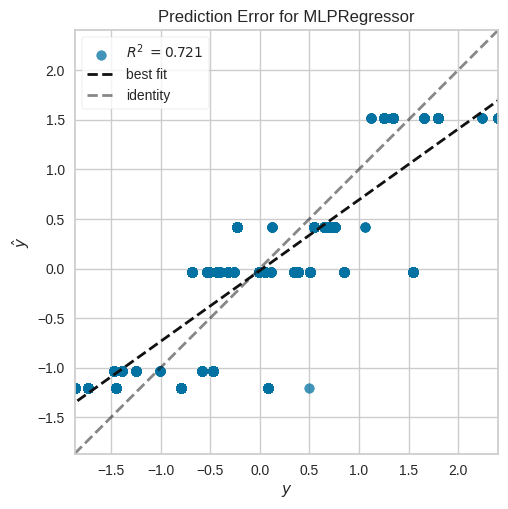

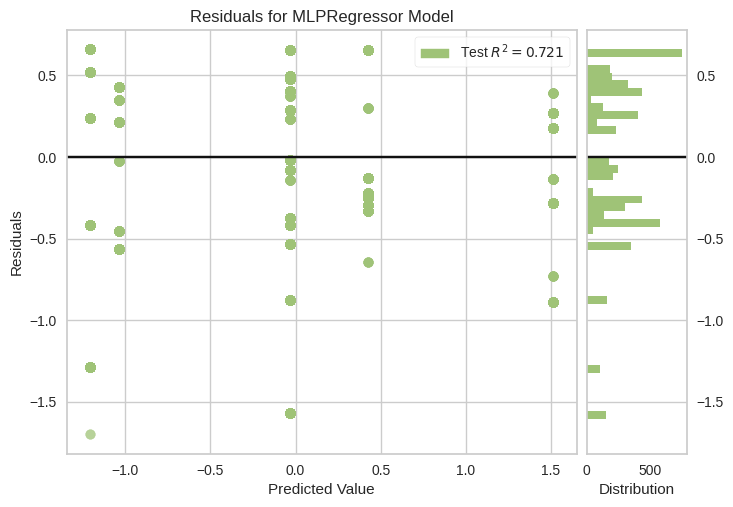

<Axes: title={'center': 'Residuals for MLPRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [202]:
# Error Visualization with Graphs (Yellowbrick) - Neural Network
visualizer_pe = PredictionError(regressor_rna_areas_train, is_fitted=True)
visualizer_pe.score(X_areas_rna_test_scaled, Y_areas_rna_test_scaled.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(regressor_rna_areas_train, is_fitted=True)
visualizer_rp.score(X_areas_rna_test_scaled, Y_areas_rna_test_scaled.ravel())
visualizer_rp.show()


  # **Neural Network Regression - Multiple**

In [203]:
# X matrix composed of the 6 multi-criteria features (area code, Size, City, State, Biome, Climate)
X_areas_rna_mult = all_areas_df[features_xai].values
X_areas_rna_mult



array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [204]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna_mult = all_areas_df[target].values.reshape(-1, 1)
Y_areas_rna_mult




array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

  **Neural Network Regression - training and testing bases**

In [205]:
# Dataset splitting (t(75% train, 25% test)
X_areas_rna_mult_train, X_areas_rna_mult_test, Y_areas_rna_mult_train, Y_areas_rna_mult_test = train_test_split(X_areas_rna_mult, Y_areas_rna_mult, test_size = 0.25, random_state = 0)
X_areas_rna_mult_train.shape, Y_areas_rna_mult_train.shape, X_areas_rna_mult_test.shape, Y_areas_rna_mult_test.shape



((17100, 6), (17100, 1), (5700, 6), (5700, 1))

  **Multiple Neural Netword for training**

In [206]:
# Standartization X
scaler_areas_rna_mult_train_x = StandardScaler()
X_areas_rna_mult_train_scaled  = scaler_areas_rna_mult_train_x.fit_transform(X_areas_rna_mult_train)
X_areas_rna_mult_train_scaled



array([[ 0.41451135, -0.15136168, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [ 0.41451135, -0.16520356, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [ 0.41451135,  1.90797261,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       ...,
       [-0.07364724,  5.29032881,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       [-0.07364724, -0.13627713,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       [ 0.41451135, -0.08802038, -0.47463678, -0.49368236, -0.44503961,
         2.04293687]])

In [207]:
# Standartization Y
scaler_areas_rna_mult_train_y = StandardScaler()
Y_areas_rna_mult_train_scaled  = scaler_areas_rna_mult_train_y.fit_transform(Y_areas_rna_mult_train)
Y_areas_rna_mult_train_scaled.ravel()



array([ 1.33939139,  1.33939139, -0.43073256, ..., -0.68259947,
       -0.68259947,  1.33939139])

In [208]:
# Params tunning for training
param = {'max_iter': [1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_train_scaled, Y_areas_rna_mult_train_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)



best_param:  {'hidden_layer_sizes': (40, 40), 'max_iter': 1000}
best_result (score):  0.9980093098438813


In [209]:
# Cross Validation Neural Network - (Multiple)
results_rna_train = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(9,9))
  scores = cross_val_score(rna, X_areas_rna_mult_train_scaled, Y_areas_rna_mult_train_scaled.ravel(), cv=kfold)
  results_rna_train.append(scores.mean())



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [210]:
regressor_rna_areas_mult_train = MLPRegressor(max_iter=1000, hidden_layer_sizes=(40,40))
regressor_rna_areas_mult_train.fit(X_areas_rna_mult_train_scaled, Y_areas_rna_mult_train_scaled.ravel())



MLPRegressor(hidden_layer_sizes=(40, 40), max_iter=1000)

In [211]:
# Score
regressor_rna_areas_mult_train.score(X_areas_rna_mult_train_scaled, Y_areas_rna_mult_train_scaled.ravel())



0.9986295220026884

In [212]:
# Prevision
prevision_rna_areas_mult_train = regressor_rna_areas_mult_train.predict(X_areas_rna_mult_train_scaled)
prevision_rna_areas_mult_train



array([ 1.33369986,  1.33388015, -0.5714    , ..., -0.69954413,
       -0.6674655 ,  1.33090482])

In [213]:
Y_areas_rna_mult_train_inverse = scaler_areas_rna_mult_train_y.inverse_transform(Y_areas_rna_mult_train_scaled)
prevision_rna_areas_mult_train = scaler_areas_rna_mult_train_y.inverse_transform(prevision_rna_areas_mult_train.reshape(-1,1))



In [214]:
Y_areas_rna_mult_train_inverse[:10].ravel()



array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [215]:
prevision_rna_areas_mult_train[:10].ravel()



array([48.5081266 , 48.50984077, 30.39492866, 22.11756777, 21.96505085,
       31.71907256, 31.72462902, 31.72407559, 52.90616494, 21.88596359])

In [216]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_train_inverse, prevision_rna_areas_mult_train)



0.14266607157130437

In [217]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_train_inverse, prevision_rna_areas_mult_train)



0.12388731573834018

In [218]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_train_inverse, prevision_rna_areas_mult_train))




0.3519762999668304

  **Multiple Neural Netword for testing**

In [219]:
# Standartization X usando scaler do traino
X_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_train_x.transform(X_areas_rna_mult_test)
X_areas_rna_mult_test_scaled



array([[ 2.04170663, -0.16440964,  0.36108383,  0.35726532,  0.68507286,
         0.61902636],
       [ 0.41451135, -0.16444416, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [-0.96860464, -0.15433026,  0.92024292,  0.92456378, -0.44503961,
        -0.33024732],
       ...,
       [-0.07364724, -0.16192432, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [ 0.41451135, -0.12633583,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       [-0.31772653, -0.13955638, -1.06305506, -1.06098081, -1.01009585,
        -0.80488415]])

In [220]:
# Standartization Y usando scaler do traino
Y_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_train_y.transform(Y_areas_rna_mult_test)
Y_areas_rna_mult_test_scaled



array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [221]:
# Score
regressor_rna_areas_mult_train.score(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())



0.9985574162856015

In [222]:
# Prevision
prevision_rna_areas_mult_test = regressor_rna_areas_mult_train.predict(X_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test



array([ 0.77927927,  1.33387026,  0.00962482, ...,  1.2437642 ,
       -0.43418121, -1.44467065])

In [223]:
Y_areas_rna_mult_test_inverse = scaler_areas_rna_mult_train_y.inverse_transform(Y_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test = scaler_areas_rna_mult_train_y.inverse_transform(prevision_rna_areas_mult_test.reshape(-1,1))



In [224]:
Y_areas_rna_mult_test_inverse[:10].ravel()



array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [225]:
prevision_rna_areas_mult_test[:10].ravel()



array([43.23683866, 48.50974673, 35.91916276, 22.13296242, 35.92158725,
       50.53159065, 31.07887596, 36.1919362 , 42.15135377, 30.78714094])

In [226]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)



0.1438382021924714

In [227]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)



0.12800498462944224

In [228]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test))


0.35777784256356937

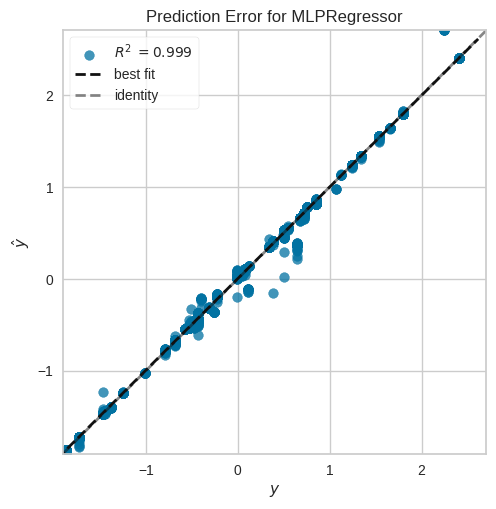

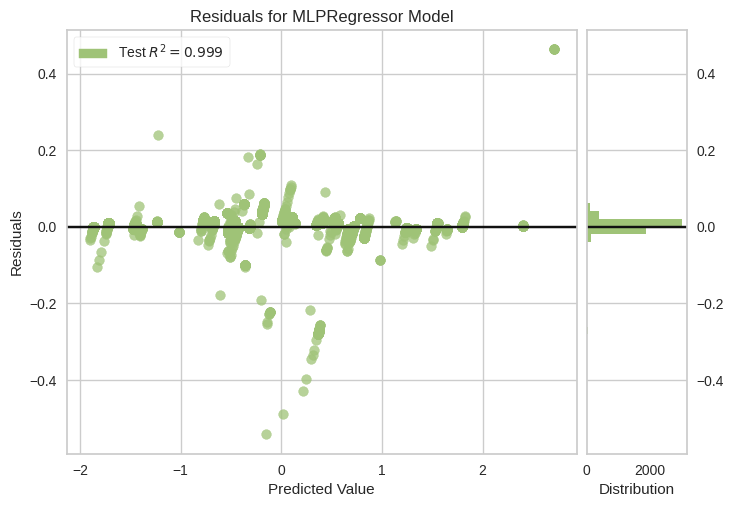

<Axes: title={'center': 'Residuals for MLPRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [229]:
# Error Visualization with Graphs (Yellowbrick) - Multiple Neural Network
visualizer_pe = PredictionError(regressor_rna_areas_mult_train, is_fitted=True)
visualizer_pe.score(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())
visualizer_pe.show()

visualizer_rp = ResidualsPlot(regressor_rna_areas_mult_train, is_fitted=True)
visualizer_rp.score(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())
visualizer_rp.show()


  # **Results Analysis (30)**







  Resultados com 30 testes na validação cruzada

In [230]:
result_polynomial_30 = results_polynomial[:30]
result_decision_tree_30 = results_tree_train[:30]
result_random_forest_30 = results_random_forest_train[:30]
result_neural_network_30 = results_rna_train[:30]


In [231]:
results_30_df = pd.DataFrame({'Polynomial': result_polynomial_30, 'Decision Tree': result_decision_tree_30, 'Random Forest': result_random_forest_30, "Neural Network": result_neural_network_30})
results_30_df



,Polynomial,Decision Tree,Random Forest,Neural Network
0,0.875937,0.999644,0.999605,0.961647
1,0.876040,0.999635,0.999600,0.968993
2,0.875993,0.999638,0.999604,0.961337
3,0.876587,0.999599,0.999606,0.964961
4,0.875070,0.999667,0.999631,0.968821
5,0.875405,0.999658,0.999643,0.962867
6,0.876214,0.999648,0.999618,0.967646
7,0.875318,0.999643,0.999609,0.965811
8,0.876657,0.999649,0.999590,0.967611
9,0.876239,0.999635,0.999546,0.963415


In [232]:
results_30_df.describe()



,Polynomial,Decision Tree,Random Forest,Neural Network
count,30.000000,30.000000,30.000000,30.000000
mean,0.876041,0.999602,0.999553,0.966400
std,0.000635,0.000110,0.000102,0.003880
min,0.874294,0.999308,0.999290,0.960881
25%,0.875705,0.999629,0.999554,0.963004
50%,0.876209,0.999643,0.999592,0.965544
75%,0.876441,0.999657,0.999606,0.968908
max,0.877066,0.999675,0.999643,0.974794


In [233]:
# Variance
results_30_df.var()



,0
Polynomial,4.038257e-07
Decision Tree,1.202310e-08
Random Forest,1.030617e-08
Neural Network,1.505177e-05


In [234]:
# Coefficient of variation (%)
(results_30_df.std() / results_30_df.mean()) * 100



,0
Polynomial,0.072539
Decision Tree,0.010969
Random Forest,0.010156
Neural Network,0.401455


  # **Statistical Tests (30)**

  **Test of normality of results**

In [235]:
alpha = 0.05



In [236]:
shapiro (result_polynomial_30), shapiro (result_decision_tree_30), shapiro (result_random_forest_30), shapiro(result_neural_network_30)



(ShapiroResult(statistic=0.953592797940232, pvalue=0.21078521751333917),
 ShapiroResult(statistic=0.5632187040197187, pvalue=2.6719854495865257e-08),
 ShapiroResult(statistic=0.6622643983063808, pvalue=4.607152657207615e-07),
 ShapiroResult(statistic=0.9471846480119627, pvalue=0.14205037020828803))

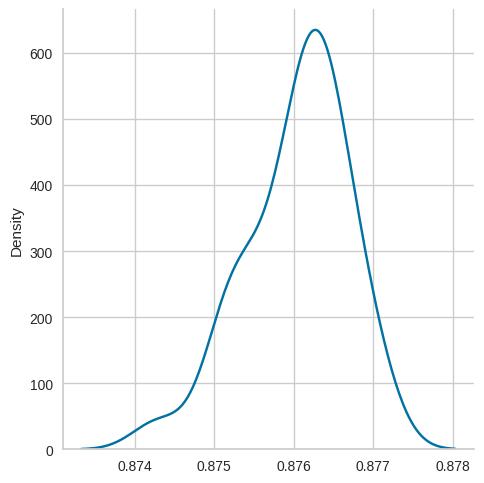

In [237]:
sns.displot(result_polynomial_30, kind = 'kde')



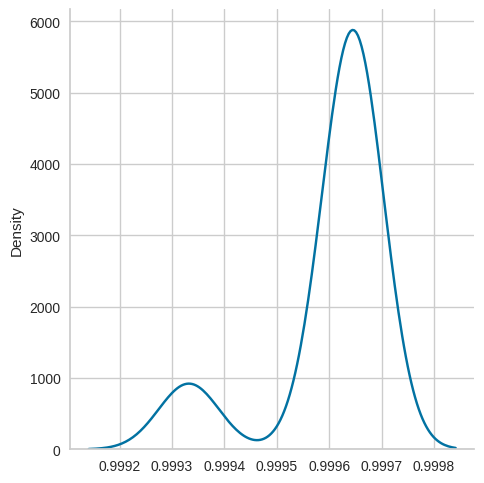

In [238]:
sns.displot(result_decision_tree_30, kind = 'kde')



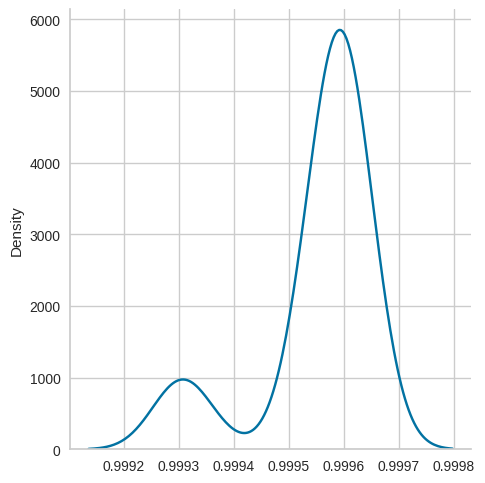

In [239]:
sns.displot(result_random_forest_30, kind = 'kde')



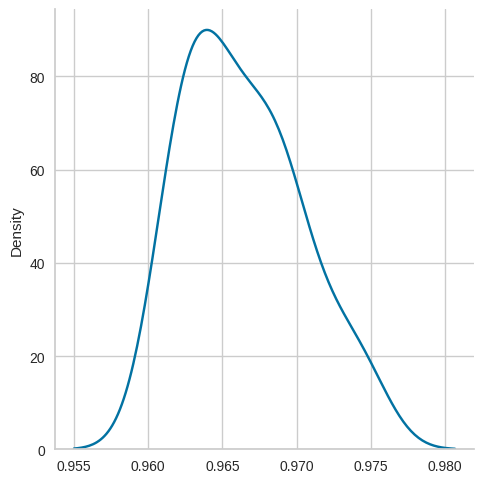

In [240]:
sns.displot(result_neural_network_30, kind = 'kde')



  **Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [241]:
# If p < alpha (0.05), the algorithm data have statistical diferences.
_, p = f_oneway(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
p



3.1302902395347765e-164

In [242]:
result_algorithm_30 = {'accuracy': np.concatenate([result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}



In [243]:
results_test_30_df = pd.DataFrame(result_algorithm_30)
results_test_30_df



,accuracy,algorithm
0,0.875937,polynomial
1,0.876040,polynomial
2,0.875993,polynomial
3,0.876587,polynomial
4,0.875070,polynomial
...,...,...
115,0.968937,neural_network
116,0.966408,neural_network
117,0.962756,neural_network
118,0.967446,neural_network


In [244]:
compare_algorithm_30 = MultiComparison(results_test_30_df['accuracy'], results_test_30_df['algorithm'])



In [245]:
statistical_test_30 = compare_algorithm_30.tukeyhsd()
print(statistical_test_30)



        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
 decision_tree neural_network  -0.0332    0.0 -0.0345 -0.0319   True
 decision_tree     polynomial  -0.1236    0.0 -0.1249 -0.1222   True
 decision_tree  random_forest     -0.0 0.9997 -0.0014  0.0013  False
neural_network     polynomial  -0.0904    0.0 -0.0917  -0.089   True
neural_network  random_forest   0.0332    0.0  0.0318  0.0345   True
    polynomial  random_forest   0.1235    0.0  0.1222  0.1248   True
--------------------------------------------------------------------


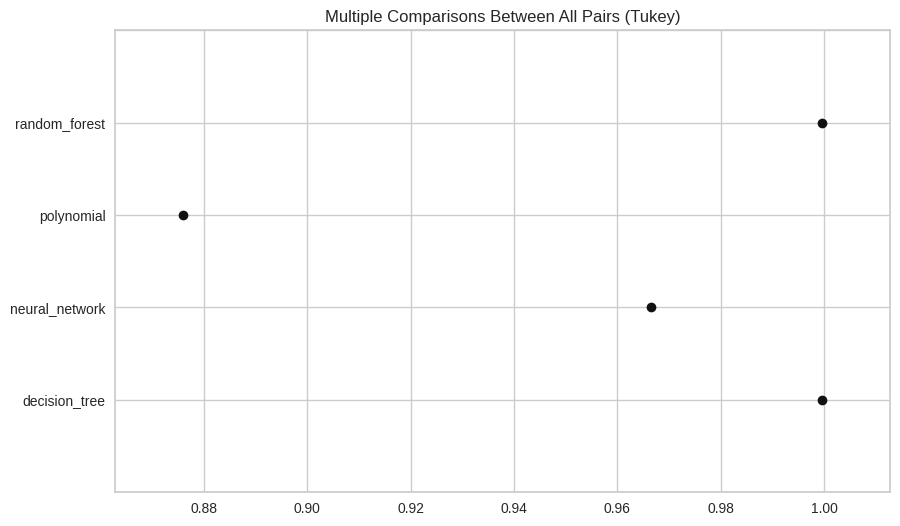

In [246]:
statistical_test_30.plot_simultaneous();



  **Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [247]:
# Conduct the Kruskal-Wallis Test
result_KW_test_30 = stats.kruskal(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
print (result_KW_test_30)



KruskalResult(statistic=105.43823691460057, pvalue=1.0516682956821444e-22)


/tmp/ipykernel_36318/2142643165.py:2: DeprecationWarning: Please import `kruskal` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  result_KW_test_30 = stats.kruskal(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)


In [248]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp



In [249]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
data_Nemenyi_30 = np.array([result_polynomial_30, result_decision_tree_30, result_random_forest_30,result_neural_network_30])
result_Nemenyi_test_30 = sp.posthoc_nemenyi_friedman(data_Nemenyi_30.T)
print (result_Nemenyi_test_30)



              0             1             2             3
0  1.000000e+00  0.000000e+00  6.360075e-09  1.435777e-02
1  0.000000e+00  1.000000e+00  2.628299e-02  2.178890e-08
2  6.360075e-09  2.628299e-02  1.000000e+00  1.043975e-02
3  1.435777e-02  2.178890e-08  1.043975e-02  1.000000e+00


  # **Results Analysis (60)**







  Resultados com 60 testes na validação cruzada

In [250]:
result_polynomial_60 = results_polynomial
result_decision_tree_60 = results_tree_train
result_random_forest_60 = results_random_forest_train
result_neural_network_60 = results_rna_train


In [251]:
results_60_df = pd.DataFrame({'Polynomial': result_polynomial_60, 'Decision Tree': result_decision_tree_60, 'Random Forest': result_random_forest_60, "Neural Network": result_neural_network_60})
results_60_df



,Polynomial,Decision Tree,Random Forest,Neural Network
0,0.875937,0.999644,0.999605,0.961647
1,0.876040,0.999635,0.999600,0.968993
2,0.875993,0.999638,0.999604,0.961337
3,0.876587,0.999599,0.999606,0.964961
4,0.875070,0.999667,0.999631,0.968821
5,0.875405,0.999658,0.999643,0.962867
6,0.876214,0.999648,0.999618,0.967646
7,0.875318,0.999643,0.999609,0.965811
8,0.876657,0.999649,0.999590,0.967611
9,0.876239,0.999635,0.999546,0.963415


In [252]:
results_60_df.describe()



,Polynomial,Decision Tree,Random Forest,Neural Network
count,60.000000,60.000000,60.000000,60.000000
mean,0.876096,0.999610,0.999560,0.966724
std,0.000777,0.000103,0.000093,0.004128
min,0.872404,0.999308,0.999290,0.957480
25%,0.875804,0.999634,0.999561,0.963092
50%,0.876285,0.999648,0.999593,0.966794
75%,0.876635,0.999657,0.999606,0.969529
max,0.877244,0.999675,0.999643,0.975877


In [253]:
# Variance
results_60_df.var()



,0
Polynomial,6.041729e-07
Decision Tree,1.054911e-08
Random Forest,8.661271e-09
Neural Network,1.703849e-05


In [254]:
# Coefficient of variation (%)
(results_60_df.std() / results_60_df.mean()) * 100



,0
Polynomial,0.088722
Decision Tree,0.010275
Random Forest,0.009311
Neural Network,0.426985


  # **Statistical Tests (60)**

  **Test of normality of results**

In [255]:
alpha = 0.05
shapiro (result_polynomial_60), shapiro (result_decision_tree_60), shapiro (result_random_forest_60), shapiro (result_neural_network_60)



(ShapiroResult(statistic=0.8422263865171614, pvalue=1.8101880974535376e-06),
 ShapiroResult(statistic=0.5260126118620166, pvalue=1.2516329452451078e-12),
 ShapiroResult(statistic=0.6456659933798445, pvalue=9.088293848169465e-11),
 ShapiroResult(statistic=0.9820271316777811, pvalue=0.5200380986141417))

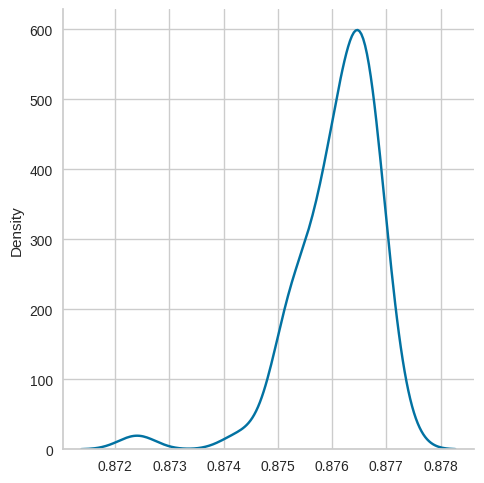

In [256]:
sns.displot(result_polynomial_60, kind = 'kde');



/tmp/ipykernel_36318/1278622938.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(result_polynomial_60, color="dodgerblue", label="Compact",)


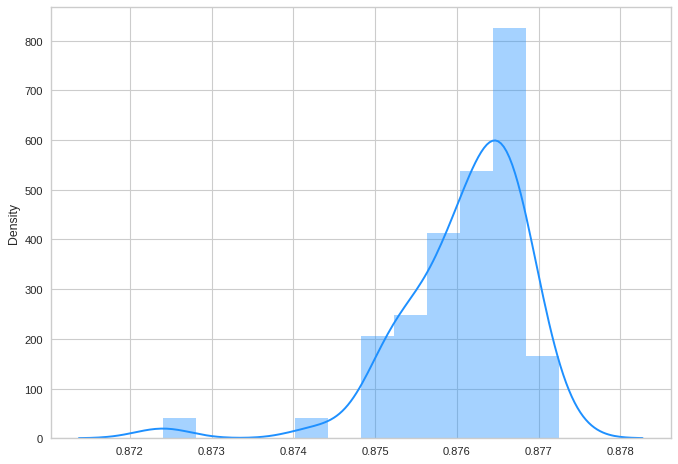

In [257]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_polynomial_60, color="dodgerblue", label="Compact",)
plt.show()



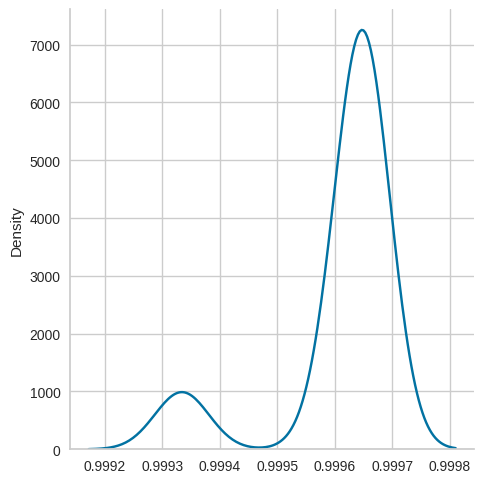

In [258]:
sns.displot(result_decision_tree_60, kind = 'kde');



/tmp/ipykernel_36318/3664183922.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(result_decision_tree_60, color="dodgerblue", label="Compact",)


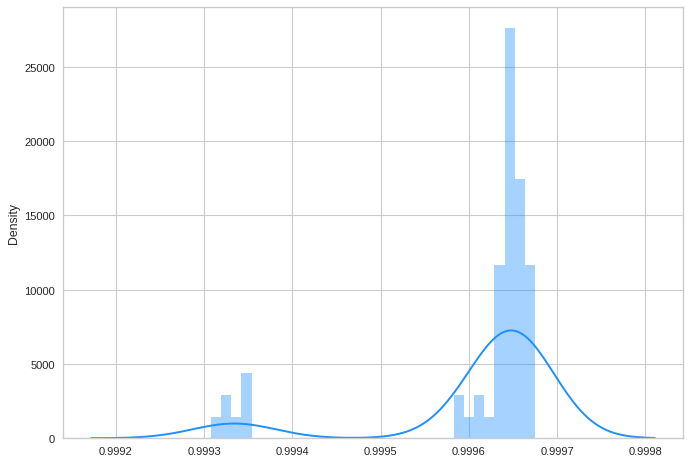

In [259]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_decision_tree_60, color="dodgerblue", label="Compact",)
plt.show()



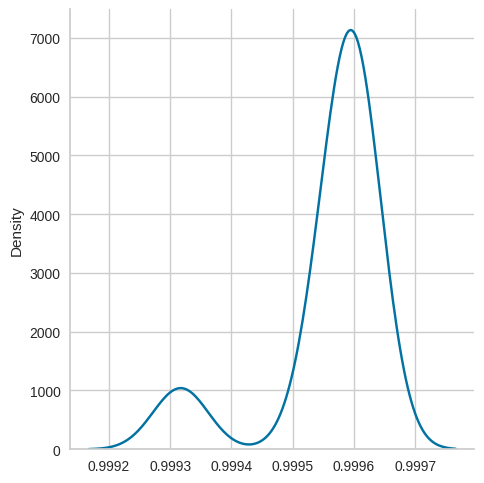

In [260]:
sns.displot(result_random_forest_60, kind = 'kde');



/tmp/ipykernel_36318/4056548655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(result_random_forest_60, color="dodgerblue", label="Compact",)


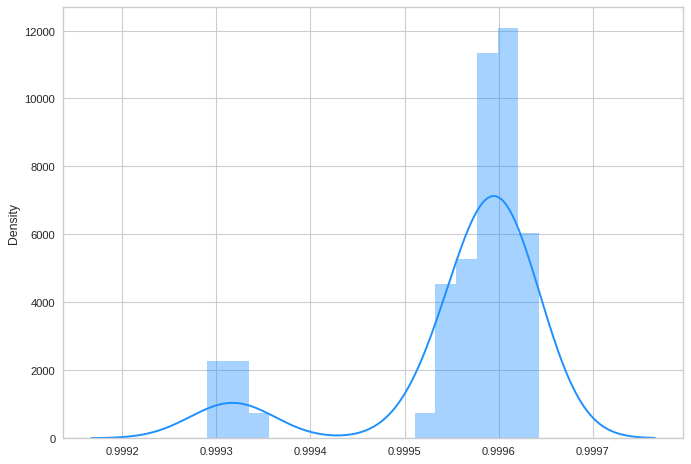

In [261]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_random_forest_60, color="dodgerblue", label="Compact",)
plt.show()



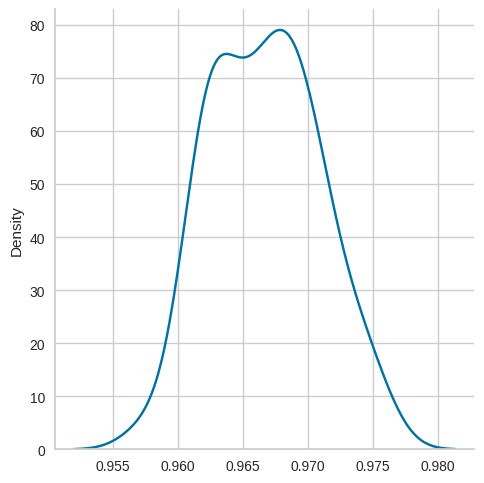

In [262]:
sns.displot(result_neural_network_60, kind = 'kde');



/tmp/ipykernel_36318/2781577431.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(result_neural_network_60, color="dodgerblue", label="Compact",)


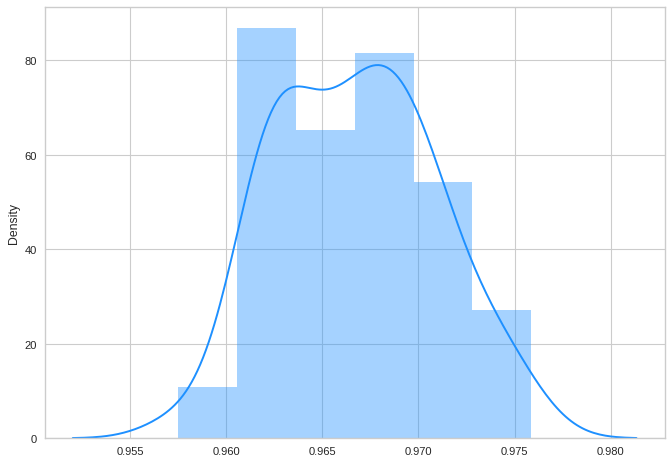

In [263]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_neural_network_60, color="dodgerblue", label="Compact",)
plt.show()



  **Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [264]:
# if p < alpha (0,05) there are statistical differences between the algorithms 
_, p = f_oneway(result_polynomial_60, result_decision_tree_60,
                result_random_forest_60, result_neural_network_60)
print(p)



0.0


In [265]:
result_algorithm_60 = {'accuracy': np.concatenate([result_polynomial_60, result_decision_tree_60, result_random_forest_60, result_neural_network_60]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree', 'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network', 'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}



In [266]:
results_test_60_df = pd.DataFrame(result_algorithm_60)
results_test_60_df



,accuracy,algorithm
0,0.875937,polynomial
1,0.876040,polynomial
2,0.875993,polynomial
3,0.876587,polynomial
4,0.875070,polynomial
...,...,...
235,0.962308,neural_network
236,0.966520,neural_network
237,0.967344,neural_network
238,0.973598,neural_network


In [267]:
compare_algorithm_60 = MultiComparison(results_test_60_df['accuracy'], results_test_60_df['algorithm'])



In [268]:
statistical_test_60 = compare_algorithm_60.tukeyhsd()
print(statistical_test_60)



        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
 decision_tree neural_network  -0.0329    0.0 -0.0339 -0.0319   True
 decision_tree     polynomial  -0.1235    0.0 -0.1245 -0.1225   True
 decision_tree  random_forest     -0.0 0.9992  -0.001  0.0009  False
neural_network     polynomial  -0.0906    0.0 -0.0916 -0.0896   True
neural_network  random_forest   0.0328    0.0  0.0318  0.0338   True
    polynomial  random_forest   0.1235    0.0  0.1225  0.1245   True
--------------------------------------------------------------------


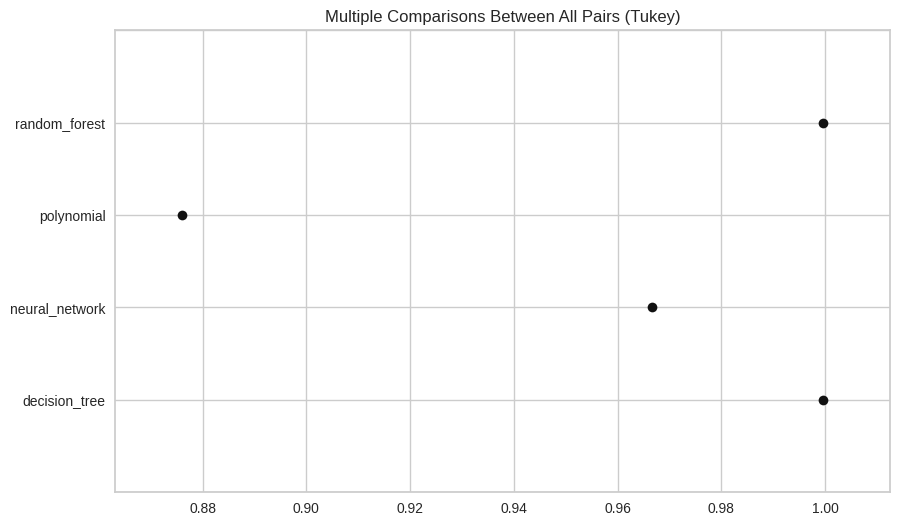

In [269]:
statistical_test_60.plot_simultaneous();



  **Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [270]:
    # Conduct the Kruskal-Wallis Test
result_KW_test_60 = stats.kruskal(result_polynomial_60, result_decision_tree_60,
                                  result_random_forest_60, result_neural_network_60)
print (result_KW_test_60)



KruskalResult(statistic=213.0967911479944, pvalue=6.2355120517606515e-46)


/tmp/ipykernel_36318/2214421154.py:2: DeprecationWarning: Please import `kruskal` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  result_KW_test_60 = stats.kruskal(result_polynomial_60, result_decision_tree_60,


In [271]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp



In [272]:
# Conduct the Nemenyi post-hoc test
data_Nemenyi_60 = np.array([result_polynomial_60, result_decision_tree_60,
                            result_random_forest_60, result_neural_network_60])
result_Nemenyi_test_60 = sp.posthoc_nemenyi_friedman(data_Nemenyi_60.T)
print (result_Nemenyi_test_60)

         0             1         2             3
0  1.00000  0.000000e+00  0.000000  1.298172e-04
1  0.00000  1.000000e+00  0.000775  5.551115e-16
2  0.00000  7.745715e-04  1.000000  4.965282e-05
3  0.00013  5.551115e-16  0.000050  1.000000e+00


In [273]:
import joblib

# Full path to the directory + filename
path_destination = '/content/drive/MyDrive/Colab Notebooks/files/extra/carbon_tree_model.pkl'

# Exporting the trained AI directly to the final folder.
joblib.dump(regressor_areas_tree_mult_train, path_destination)

print("AI successfully saved to the final folder and ready for the Dashboard!")

AI successfully saved to the final folder and ready for the Dashboard!
